In [228]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [229]:
X_train = pd.read_csv("X_wo_train.csv")
X_test = pd.read_csv("X_wo_test.csv")

y_train = pd.read_csv("y_wo_train.csv")
y_test = pd.read_csv("y_wo_test.csv")

In [230]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [231]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (274676, 14)
X_test : (68719, 14)
y_train: (274676,)
y_test : (68719,)


In [ ]:
#Target encoding di model e manufacturer
target_cols = [
    "manufacturer",
    "model"
]

''' sostiuisce con il prezzo medio per marca ed il prezzo medio per modello i valori stringa'''


global_mean = y_train.mean()

for col in target_cols:

    train_col = X_train[col].fillna("missing")
    test_col = X_test[col].fillna("missing")

    target_mean = y_train.groupby(train_col).mean()

    X_train[col] = (
        train_col
        .map(target_mean)
        .fillna(global_mean)
    )

    X_test[col] = (
        test_col
        .map(target_mean)
        .fillna(global_mean)
    )

In [ ]:
onehot_cols = [
    "condition",
    "cylinders",
    "fuel",
    "title_status",
    "transmission",
    "drive",
    "size",
    "type",
    "paint_color",
    "state"
]

#one hot encoding delle feature categoriche con cardinalità non troppo elevata
X_train = pd.get_dummies(
    X_train,
    columns=onehot_cols,
    dummy_na=True
)

X_test = pd.get_dummies(
    X_test,
    columns=onehot_cols,
    dummy_na=True
)

In [234]:
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [235]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [ ]:
#eliminazione dei valori che non rientrano nel range di prezzi

mask_train = y_train.between(500,80000)

X_train = X_train.loc[mask_train]
y_train = y_train.loc[mask_train]
mask_test = y_test.between(500, 80000)

X_test = X_test.loc[mask_test]
y_test = y_test.loc[mask_test]

In [ ]:
from datetime import datetime
current_year = datetime.now().year

#creazione della feature età dell'auto

X_train["car_age"] = current_year - X_train["year"]
X_test["car_age"] = current_year - X_test["year"]

In [238]:
model = XGBRegressor(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [239]:
model.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [240]:
y_pred = model.predict(X_test)

In [241]:
mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print(f"RMSE: {rmse:,.2f}")
print(f"MAE : {mae:,.2f}")
print(f"R²  : {r2:.4f}")
# Analisi errori


RMSE: 3,860.29
MAE : 2,259.44
R²  : 0.9127


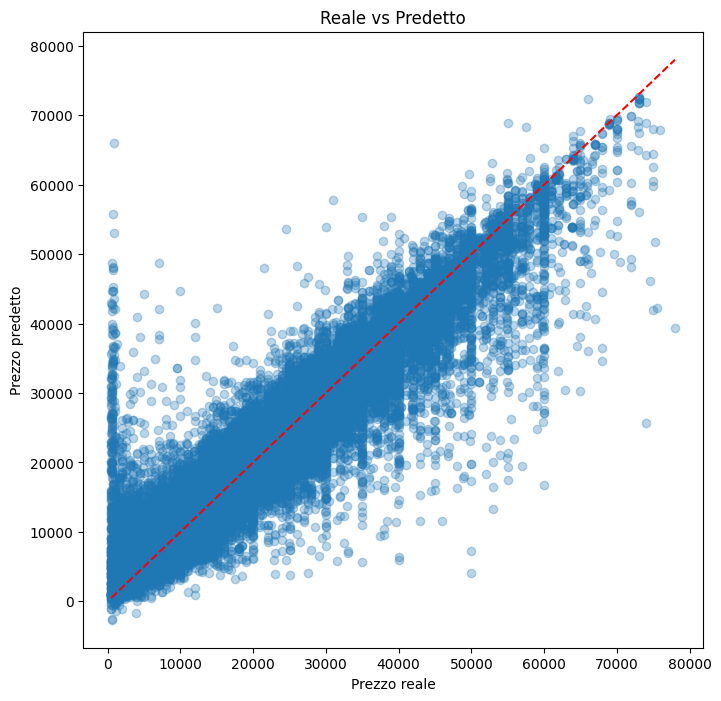

In [242]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.xlabel("Prezzo reale")
plt.ylabel("Prezzo predetto")
plt.title("Reale vs Predetto")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.show()